In [1]:
# !nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod
from neuron import h, gui

# 加载基础的 NEURON GUI 库
h.load_file("nrngui.hoc")

# 依次打开各个 HOC 文件
h.load_file("n128.hoc")               # 几何文件
h.load_file("axon_sections.hoc")      # 轴突部分
h.load_file("basal_dendrite.hoc")     # 基础树突
h.load_file("apical_dendrite.hoc")    # 顶端树突
h.load_file("apical_trunk.hoc")       # 顶端树干
h.load_file("radiatum.hoc")           # 放射区
h.load_file("init.hoc")               # 初始化设置
h.load_file("addgraph.hoc")           # 添加图形显示
from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from matplotlib.ticker import FuncFormatter
def format_func(value, tick_number):
    return f'{value:.0f}'  # 将刻度值格式化为小数点后两位

def plot_curve(ax2,x,y,color='black',title='', linestyle='-',xlim=[0,100],dx=20,
               ylim=[0,10],dy=5.0, fontsize=10, alpha = 1.0, xlabel='Time/ms', 
               ylabel = 'Frequency/Hz', label='',ynum_decimals =1, 
               nonscatter=True, s0=10):
    if nonscatter:
        if color:
            ax2.plot(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, label=label)
        else:
            ax2.plot(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label)
    else:
        if color:
            ax2.scatter(x,y,color=color,linewidth=2,linestyle=linestyle,alpha=alpha, 
                        label=label, s=s0)
        else:
            ax2.scatter(x,y,linewidth=2,alpha=alpha, linestyle=linestyle,label=label,
                        s=s0)
        
    ax2.set_xlabel(xlabel,font2)
    ax2.set_ylabel(ylabel,font2)
    
    # def format_funcx(value, tick_number, num_decimals=xnum_decimals):
    #     if num_decimals==0:
    #         return f'{value:.0f}'
    #     return f'{value:.{num_decimals}f}'

    def format_funcy(value, tick_number, num_decimals=ynum_decimals):
        if num_decimals==0:
          return f'{value:.0f}'
        return f'{value:.{num_decimals}f}'

    # if dx:
    #     ax2.set_xticks(np.arange(xlim[0], xlim[1] + dx, dx))
    #     ax2.set_xticklabels(ax2.get_xticks(), fontsize=fontsize, weight='bold')
    #     ax2.set_xlim([xlim[0], xlim[1]])
    #     ax2.xaxis.set_major_formatter(FuncFormatter(format_funcx))

    if dy:
        ax2.set_yticks(np.arange(ylim[0], ylim[1] + dy, dy))
        ax2.set_yticklabels(ax2.get_yticks(), fontsize=fontsize, weight='bold')
        ax2.set_ylim([ylim[0], ylim[1]])
        ax2.yaxis.set_major_formatter(FuncFormatter(format_funcy))
        
  
    if dx:
       ax2.set_xticks(np.arange(xlim[0],xlim[1]+dx,dx))
       ax2.set_xticklabels(np.arange(xlim[0],xlim[1]+dx,dx),fontsize=10,weight='bold')
       ax2.set_xlim(xlim)
    # if ylim:
    #    ax2.set_yticks(np.arange(ylim[0],ylim[1]+dy,dy))
    #    ax2.set_yticklabels(np.arange(ylim[0],ylim[1]+dy,dy),fontsize=10,weight='bold')
    #    ax2.set_ylim(ylim)
    if title:
       ax2.set_title('{0}'.format(title),fontsize=12,weight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    if label:
       ax2.legend(loc='best',prop=font2,edgecolor='white')

--No graphics will be displayed.
dlopen failed - 
x86_64/.libs/libnrnmech.so: undefined symbol: use_cachevec
NEURON: na3 is not a MECHANISM
 in init.hoc near line 72
 			insert na3  gbar_na3 = gna
             ^
        xopen("init.hoc")
      execute1("{xopen("in...")
    load_file("init.hoc")
NEURON: hoc_Load_file init.hoc
 in init.hoc near line 0
 ^
        load_file("init.hoc")


Check neuron_morph
	 Note: diam values less than 0.3um are set to 0.3um!
Diam was changed for: 0  points



RuntimeError: hocobj_call error: hoc_execerror: hoc_Load_file init.hoc

# active

-70.00000069740193


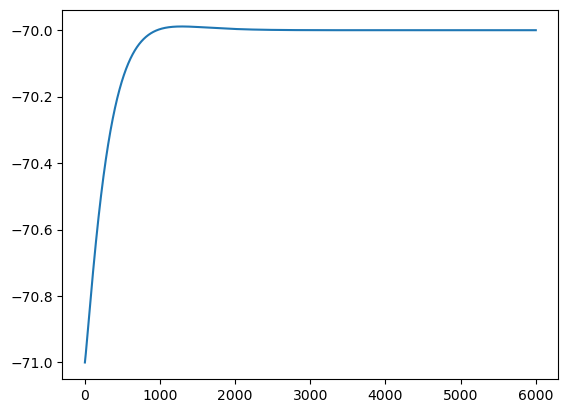

In [ ]:
h.init()
run_dt = 0.1
h.dt = run_dt
h.tstop = 600.
h.v_init = -71
recv = h.Vector().record(h.soma(0.5)._ref_v)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()


go()
recv0 =  np.array(recv.to_python())
plt.plot(recv0)
print(recv0[5000])

# resting state: active: -70 mV


# passive

-71.3


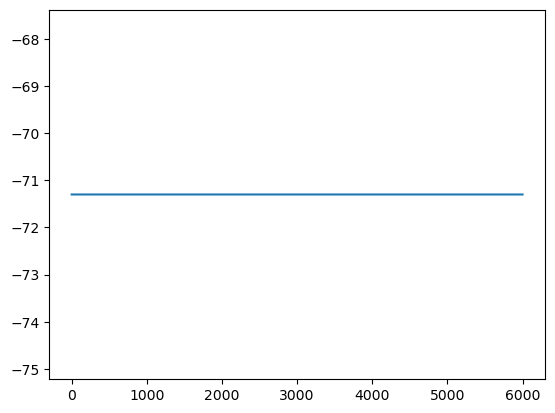

In [5]:
passive = True
if passive:
    for sec in h.allsec():
        # 检查 section 是否有主动离子通道
        if h.ismembrane("hd", sec=sec):
            # 将电导设置为0
            sec.ghdbar_hd = 0.
        if h.ismembrane("cal", sec=sec):
            sec.gcalbar_cal = 0.
        if h.ismembrane("cat", sec=sec):
            sec.gbar_cat = 0.
        if h.ismembrane("kad", sec=sec):
            sec.gkabar_kad = 0.
        if h.ismembrane("kap", sec=sec):
            sec.gkabar_kap = 0.
        if h.ismembrane("kdr", sec=sec):
            sec.gkdrbar_kdr = 0.
        if h.ismembrane("na3",sec=sec):
            sec.gbar_na3 = 0.
        if h.ismembrane("nax",sec=sec):
            sec.gbar_nax = 0.

h.init()
run_dt = 0.1
h.dt = run_dt
h.tstop = 600.
h.v_init = -71.3
recv = h.Vector().record(h.soma(0.5)._ref_v)

# Function to initialize the simulation
def initialize():
    h.t = 0
    h.finitialize(h.v_init)
    h.fcurrent()

# Function to integrate the simulation
def integrate():
    while h.t < h.tstop:
        h.fadvance()

# Function to run the simulation
def go():
    initialize()
    integrate()


go()
recv0 =  np.array(recv.to_python())
plt.plot(recv0)
print(recv0[5000])